In [1]:
import os
import os.path as osp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import dsrl.infos as dsrl_infos

### Bootstrap Confidence Interval

In [2]:
# algotype = "safetd3"
# DATA_PATH = f"/mnt/d/books/iitm/phd/offline_mpc/{algotype}/"
DATA_PATH = "/home/returaj/Documents/research/offline_safe_rl/"

In [3]:
def load_data_as_array(hyperparams, algo, task, type):
    # load csv to dataframe
    # path = f"{DATA_PATH}/{algo}/{task}/{type}"
    path = f"{DATA_PATH}/{hyperparams}/{algo}/{task}/{type}"
    abs_filenames = sorted([osp.join(path, f) for f in os.listdir(path)])
    dfs = []
    for i, f in enumerate(abs_filenames):
        d = pd.read_csv(f)
        if "Wall time" in d.columns:
            d = d.drop(columns=["Wall time"])
        d = d.rename(columns={"Value": f"seed_{i}"})
        dfs.append(d)
 
    # join dataframes based on Step
    df = dfs[0]
    for d in dfs[1:]:
        df = df.join(d.set_index("Step"), on="Step", how="right")
    
    df = df.drop(columns=["Step"])
    df = df.reset_index(drop=True)
    for col in df.columns:
        avg = (df[col].shift(1) + df[col].shift(-1)) / 2
        df[col] = df[col].where(df[col].notna(), avg)
        if pd.isna(df.at[0, col]):
            df.at[0, col] = df.at[1, col]
        if pd.isna(df.at[len(df) - 1, col]):
            df.at[len(df) - 1, col] = df.at[len(df) - 2, col]
    
    # num_seeds X T
    arr = df.to_numpy().T
    return arr

In [4]:
def normalize_reward(arr, baseline, env_name):
    env_name = env_name.replace("_", "")
    # max_reward = dsrl_infos.MAX_EPISODE_REWARD[env_name]
    min_reward = dsrl_infos.MIN_EPISODE_REWARD[env_name]
    max_reward = dsrl_infos.MAX_EPISODE_REWARD[env_name]
    return (arr - min_reward) / (baseline - min_reward + 1.0)
    # return arr

def normalize_cost(arr, baseline, env_name):
    env_name = env_name.replace("_", "")
    max_cost = dsrl_infos.MAX_EPISODE_COST[env_name]
    return (arr - baseline) / (max_cost - baseline + 1.0)
    # return (arr+1)/ (baseline+1)
    # return arr

In [5]:
def bootstrap_confidence_interval(data, n_bootstrap=1000, confidence_level=0.95):
    """
    Function to compute bootstrap confidence intervals for time-series data and plot the results.
    
    Parameters:
    data (list of array-like): List of n time-series datasets (arrays) of the same length.
    n_bootstrap (int): Number of bootstrap resamples.
    confidence_level (float): Confidence level for the interval (default is 0.95).
    
    Returns:
    mean, lower_bound, upper_bound: The lower and upper bounds of the confidence interval at each time step.
    """
    # Convert data to numpy array (shape: 5 x T, where T is the number of time steps)
    data = np.array(data)
    
    # Ensure all time-series are of the same length
    assert len(set([len(ts) for ts in data])) == 1, "All time-series must be of the same length!"
    
    # Number of time steps
    num_data, T = data.shape
    
    # Arrays to store bootstrap results
    bootstrapped_means = np.zeros((n_bootstrap, T))
    
    # Perform bootstrap resampling for each time step
    for i in range(n_bootstrap):
        # Resample with replacement from the num_data time-series at each time step
        resampled_indices = np.random.choice(num_data, (num_data,), replace=True)
        bootstrapped_means[i, :] = np.mean(data[resampled_indices], axis=0)
    
    # Compute the confidence interval at each time step
    alpha = (1 - confidence_level) / 2
    lower_bound = np.percentile(bootstrapped_means, 100 * alpha, axis=0)
    upper_bound = np.percentile(bootstrapped_means, 100 * (1 - alpha), axis=0)
    
    mean_time_series = np.mean(bootstrapped_means, axis=0)

    return mean_time_series, lower_bound, upper_bound

In [6]:
def light_color(color, amount=0.7):
    try:
        c = mcolors.cnames[color]  # convert named color to hex
    except KeyError:
        c = color  # if it's not a named color, it might already be hex or RGB

    rgb = mcolors.to_rgb(c)  # convert to RGB format
    light_color = [(1 - amount) * channel + amount for channel in rgb]  # blend with white
    return light_color


def plot_confidence_interval(means, lowers, uppers, labels, colors, markers, title, xlabel, ylabel,
                             axis=None, is_ylabel=True, is_xlabel=True, is_title=True, 
                             facecolor="#fafafa", fontsize=24, half_timestep=True):
    ax = axis
    if axis is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    T = min([len(x) for x in means]) #len(means[0])
    x = (np.arange(T) + 1)
    x = x * 2 if half_timestep else x
    x = x / 100

    # set light background color
    ax.set_facecolor(facecolor)

    ymin, ymax = 10.0, 0.0
    for m, l, u, label, c, mks in zip(means, lowers, uppers, labels, colors, markers):
        linestyle = '-'
        if np.all(m == l) == 1:
            linestyle = '--'
        ax.plot(x, m[:T], color=c, lw=4.3, label=label, linestyle=linestyle, marker=mks, markevery=7, markersize=10)
        ax.fill_between(x, l[:T], u[:T], color=light_color(c), alpha=0.4)
        
        ymin, ymax = min(min(m[:T]), ymin), max(max(m[:T]), ymax)

    if (ylabel == 'Normalized Cost') or (ylabel == 'Normalized CVaR Cost'):
        ymin, ymax = min(ymin, 0.0) - 0.1, min(ymax, 1.0) + 0.2
        ax.set_ylim(ymin, ymax)
    
    if is_title:
        ax.set_title(title, fontsize=fontsize)
    if is_ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize)
    if is_xlabel:
        ax.set_xlabel(xlabel, fontsize=fontsize)

    ax.grid(visible=True, which='both', linestyle='--', linewidth=1.2, alpha=0.9)
    ax.tick_params(axis='both', which='major', labelsize=12)
    # if ylabel in ("ep_reward", "ep_valid_bc"):
    #     ax.legend(loc='lower right')
    # elif ylabel in ("ep_cost",):
    #     ax.legend(loc="upper right")  
    if axis is None:    
        return fig, ax
    else:
        return ax
    

def plot_bar_confidence_interval(means, lowers, uppers, labels, colors, title, xlabel, ylabel,
                                 axis=None, is_ylabel=True, is_xlabel=True, is_title=True,
                                 facecolor="#fafafa", fontsize=24):
    del colors, xlabel
    
    colors = ["orange", "green"]
    ax = axis
    if axis is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    
    last_m = [m[-1] for m in means]
    last_l = [l[-1] for l in lowers]
    last_u = [u[-1] for u in uppers]

    yerr = np.array([
        np.array(last_m) - np.array(last_l),
        np.array(last_u) - np.array(last_m)
    ])

    xgap = 1.5
    xpos = np.arange(len(labels))*xgap

    # set light background color
    ax.set_facecolor(facecolor)

    bars = ax.bar(xpos, last_m, yerr=yerr, capsize=8, color=colors, edgecolor='black')
    ax.set_xticks(xpos)
    
    if is_title:
        ax.set_title(title, fontsize=fontsize)
    if is_ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize)
    if is_xlabel:
        ax.set_xticklabels(labels, fontsize=fontsize)
        for bar, label in zip(bars, labels):
            bar.set_label(label)

    return ax
  

In [7]:
cmky_map = {
    "cornflowerblue": "#4F81BD",
    "orange": "#E69F00",
    "coral": "#D97662",
    "mediumseagreen": "#6BA66C",
    "orchid": "#B57BB3",
    "blue": "#0072B2",
}

BASE_COLORS = ["black", cmky_map["cornflowerblue"], cmky_map["orange"], cmky_map["coral"],
               cmky_map["orchid"], cmky_map["mediumseagreen"], "purple", "red", "yellow", "pink"]

MARKERS = [None, '*', 'o', '^', 'd', 's', '.']

HATCH_PATTERNS = [None, '/', '\\', '.', 'o', '*', 'x', 'o', 'O', '.', '*']

In [8]:
# ALGOS = [("preferred_bc", "BC-Pref"), ("ppl/hz_5", "PPL"), ("safedice", "SafeDICE"), ("safecl/batch_32/hz_300/limit_0.85_temp_0.1_th_0.0", "SafeCL (our)"),]
ALGOS = [("preferred_bc", "BC-Pref"), ("safecl/batch_32/hz_100/limit_0.85_temp_0.1_th_0.0", "SafeCL (100)"), ("safecl/batch_32/hz_300/limit_0.85_temp_0.1_th_0.0", "SafeCL (300)")]

# ALGOS = [("cdt", "Constrained-RL"), ("bc", "BC-Union"), ("preferred_bc", "Safe-BC"), ("ppl/hz_5", "PPL"), ("safecl/batch_64/hz_10/norm", "SafeCL (our)"),]

# ALGOS = [("cdt", "Constrained-RL"), ("true_cost_safetd3/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/", "OSIL (w/ true cost)"), ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", "OSIL (w/o true cost)"),]

# ALGOS = [("preferred_bc", "BC-Pref"), ("bc", "BC-Union"), ("ppl/hz_5", "ppl"), ("safedice", "safedice"), ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.005_vbeta_0.001", "w/o bootstrap"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.005_vbeta_0.001/no_contrastive", "w/o contrastive"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.005_vbeta_0.001/contrastive", "SafeTD3 (our)")]

# ALGOS = [
#     [("preferred_bc", "BC-Pref"), ("safemil/loss_1_bce_bc_transition/bag_128/hz_5", "transition_weighted"), ("safemil/loss_1_bce/bag_128/hz_5", "trajectory_weighted")],
#     [("preferred_bc", "BC-Pref"), ("safemil/loss_1_bce_bc_transition/bag_128/hz_10", "transition_weighted"), ("safemil/loss_1_bce/bag_128/hz_10", "trajectory_weighted")]
# ]

In [9]:
def generate_performance_figures(hyperparams, tasks):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    num_tasks = len(tasks)
    single_fig, single_axs = plt.subplots(len(types), num_tasks, figsize=(25, 13.7), sharex='col')
    for y, task in enumerate(tasks):
        for x, type in enumerate(types):
            # preferred policy performance
            data = load_data_as_array(hyperparams, "preferred_bc", task, type)
            m, _, _ = bootstrap_confidence_interval(data)
            if type == "ep_reward":
                baseline = m[-1]
            else:
                baseline = m[-1]
            
            means, lowers, uppers, labels = [], [], [], []
            for a, suffix in ALGOS: # ALGOS[y]
                data = load_data_as_array(hyperparams, a, task, type)
                m, l, u = bootstrap_confidence_interval(data)
                if a == "preferred_bc":
                    m = l = u = np.ones(50) * baseline
                if type == "ep_reward":
                    m, l, u = (normalize_reward(x, baseline, task) for x in (m, l, u))
                else:
                    m, l, u = (normalize_cost(x, baseline, task) for x in (m, l, u))
                means.append(m)
                lowers.append(l)
                uppers.append(u)
                labels.append(suffix)
            colors = BASE_COLORS[:len(labels)]
            markers = MARKERS[:len(labels)]
            if type == "ep_cost":
                ylabel = "Normalized Cost"
            elif type == "ep_reward":
                ylabel = "Normalized Return"
            else:
                ylabel = "Normalized CVaR Cost"
            
            ax = plot_confidence_interval(means, lowers, uppers, labels=labels,
                                          colors=colors, markers=markers, title=task.replace("_", " "), 
                                          xlabel="training steps " + r"$ \, (\times 10^6)$",
                                          ylabel=ylabel, axis=single_axs[x, y], is_ylabel=y==0,
                                          is_xlabel=x==2, is_title=x==0)

            # ax = plot_bar_confidence_interval(means, lowers, uppers, labels=labels,
            #                                 colors=colors, title=task.replace("_", " "), 
            #                                 xlabel="training steps " + r"$ \, (\times 10^6)$",
            #                                 ylabel=ylabel, axis=single_axs[x, y], is_ylabel=y==0, is_xlabel=x==2, is_title=x==0)
    plt.subplots_adjust(hspace=0.15) 
    return single_fig, single_axs

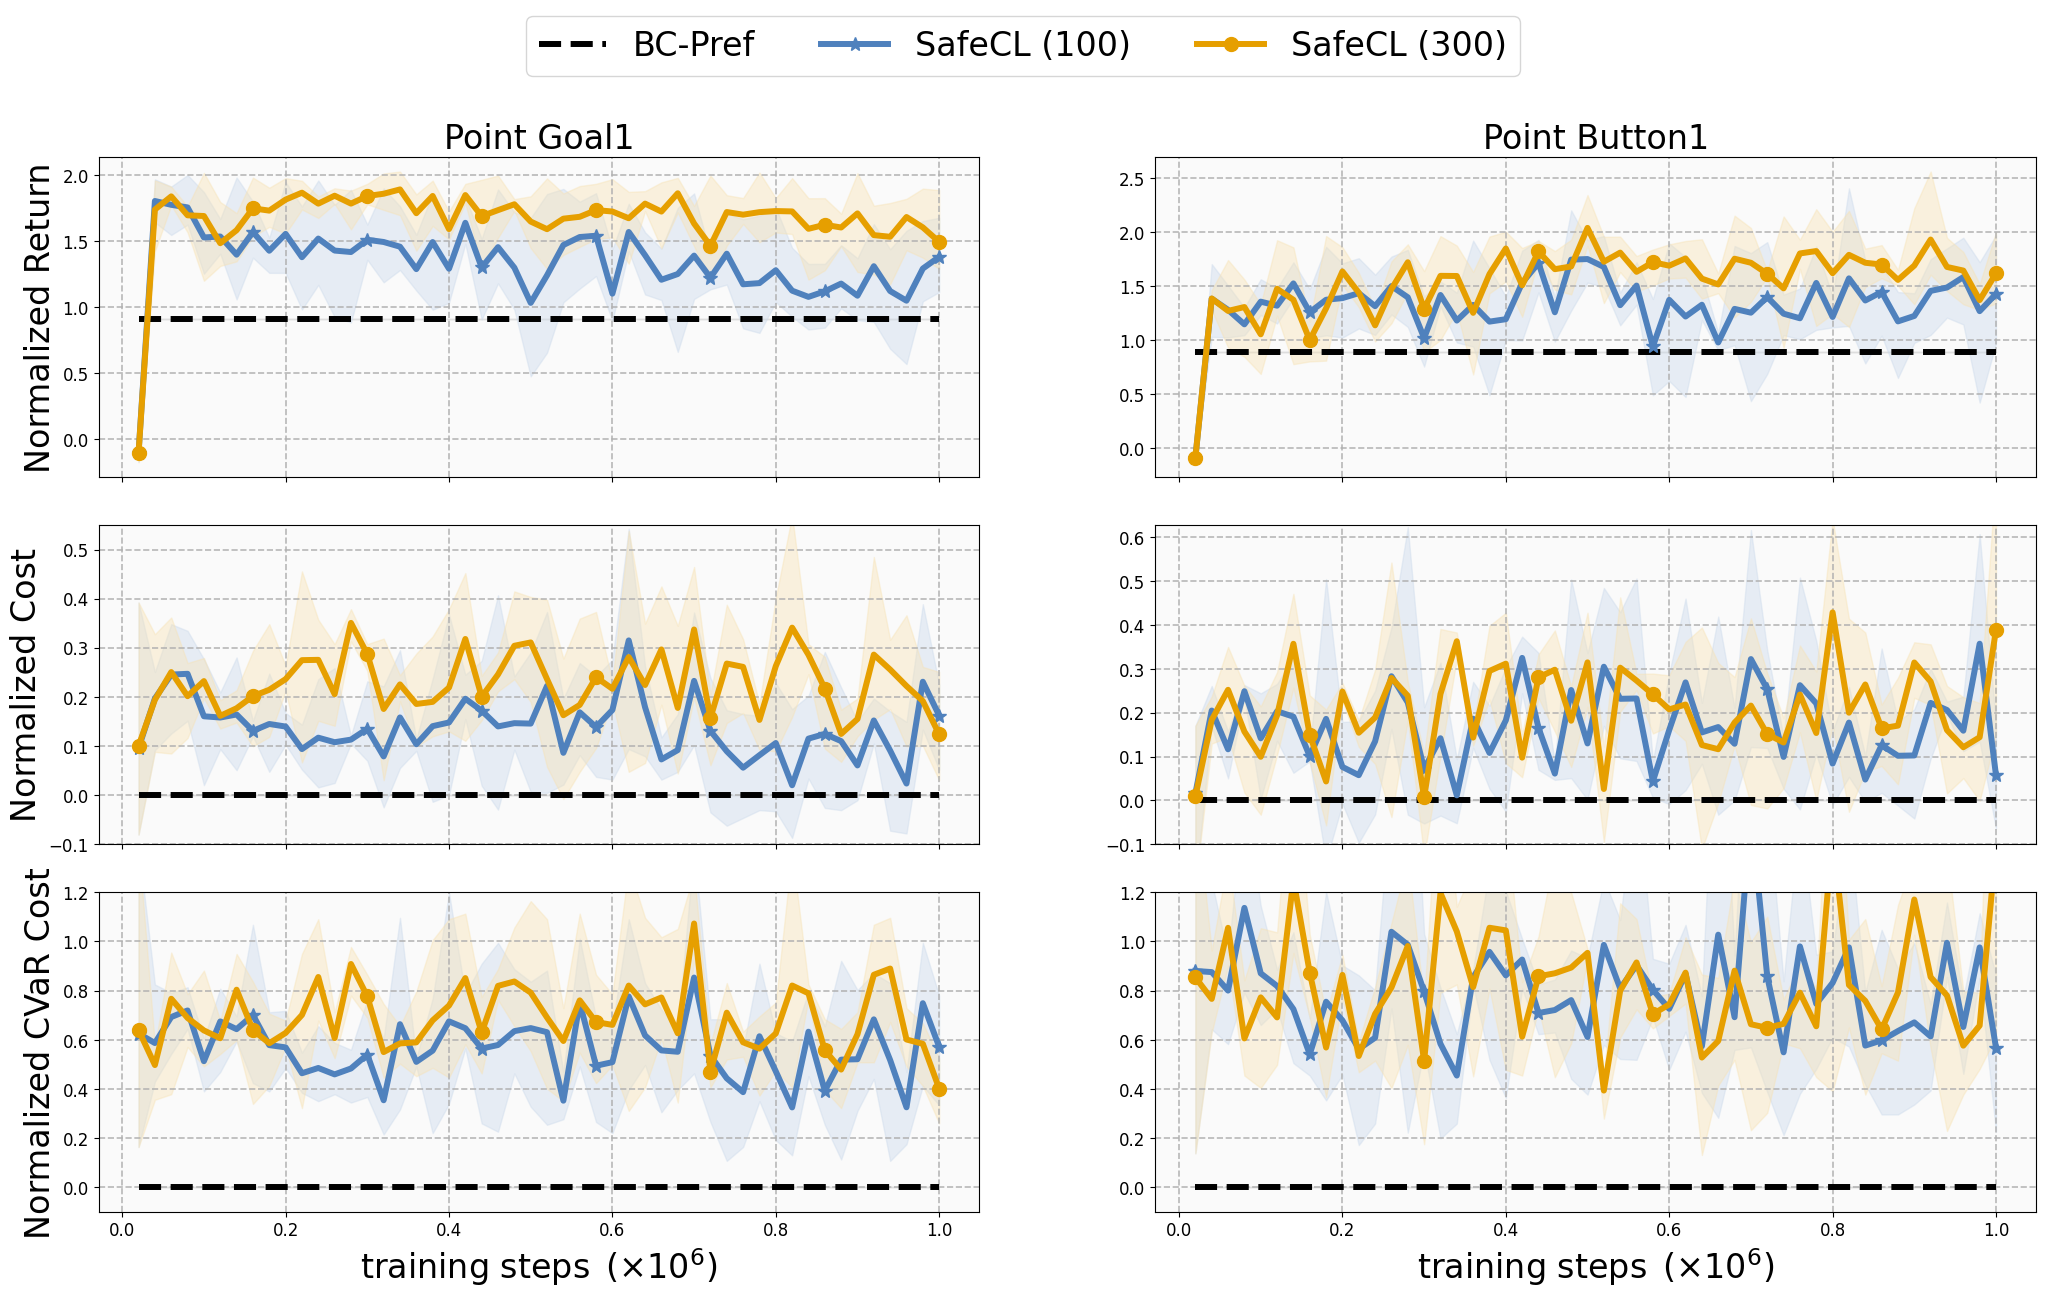

In [10]:
hyperparams = "neg_union_cost_only/neg_50"

key = "performance_comparison"
tasks = ["Point_Goal1", "Point_Button1"] # Point_Push1
# tasks = ["Walker2d_Velocity", "Swimmer_Velocity", "Ant_Velocity"] # Hopper_Velocity
fig, ax = generate_performance_figures(hyperparams, tasks)
handles, labels = ax[0, 0].get_legend_handles_labels()
# Create a single legend for all subplots
fig.legend(handles, labels, loc='upper center', ncol=len(ALGOS), fontsize=24)

#### Compare $D_{pref}$ and $\bar{D}_{pref}$

In [11]:
def generate_compare_pref_data_figures(hyperparams, algo, tasks, types):
    # types = ("train_pref_reward", "train_bar_pref_reward")
    num_tasks = len(tasks)
    single_fig, single_axs = plt.subplots(1, num_tasks, figsize=(18, 5), sharex='col')
    for y, task in enumerate(tasks):
        
        means, lowers, uppers, labels = [], [], [], []
        for type, suffix in types:
            data = load_data_as_array(hyperparams, algo, task, type)
            m, l, u = bootstrap_confidence_interval(data)
            
            means.append(m)
            lowers.append(l)
            uppers.append(u)
            labels.append(suffix)
            
            if type == "train_pref_reward":
                ylabel = "Return"
            elif type == "train_pref_cost":
                ylabel = "Cost"

        colors = BASE_COLORS[1:len(labels)+1]
        markers = MARKERS[1:len(labels)+1]
        
        ax = plot_confidence_interval(means, lowers, uppers, labels=labels,
                                      colors=colors, markers=markers, title=task.replace("_", " "), 
                                      xlabel="training steps " + r"$ \, (\times 10^6)$",
                                      ylabel=ylabel, axis=single_axs[y], is_ylabel=y==0,
                                      is_xlabel=True, is_title=True, fontsize=15, half_timestep=False)

    plt.subplots_adjust(hspace=0.15, wspace=0.28) 
    return single_fig, single_axs

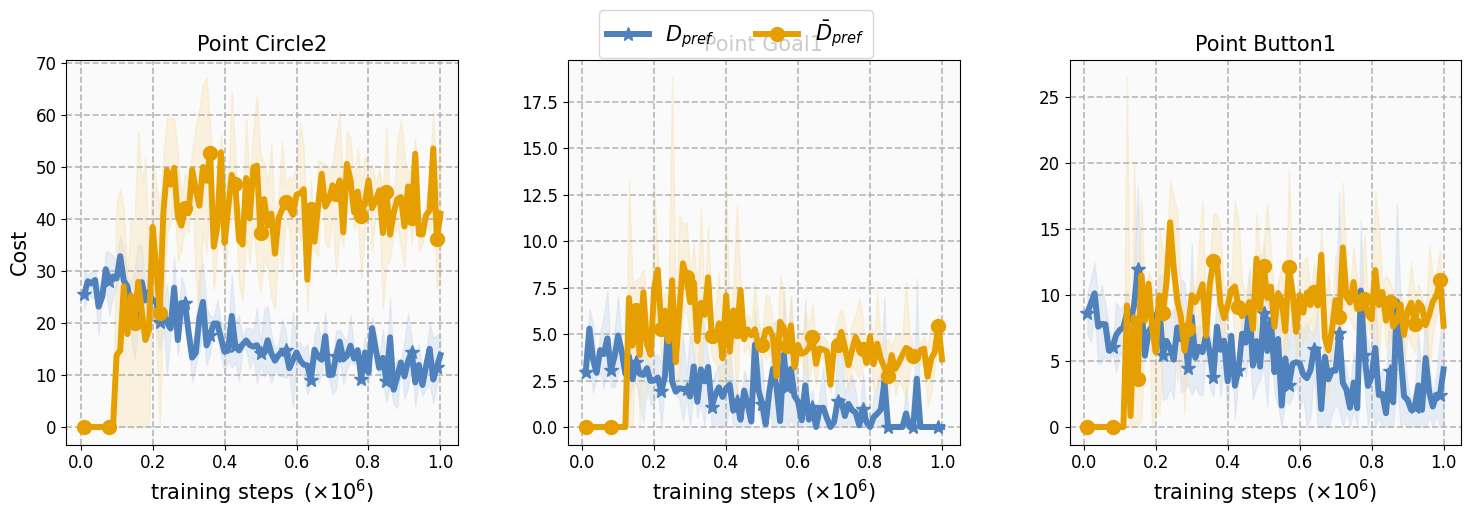

In [ ]:
key = "compare_train_data"
algo = "safecl/batch_32/hz_100/limit_0.85_temp_0.1_th_0.0"

hyperparams = "neg_union_full/neg_50"

# types = [("train_pref_reward", r"$D_{pref}$"), ("train_bar_pref_reward", r"$\bar{D}_{pref}$")]
types = [("train_pref_cost", r"$D_{pref}$"), ("train_bar_pref_cost", r"$\bar{D}_{pref}$")]

tasks = ["Point_Circle2", "Point_Goal1", "Point_Button1"] # Point_Push1
# tasks = ["Walker2d_Velocity", "Swimmer_Velocity", "Ant_Velocity"] # Hopper_Velocity
fig, ax = generate_compare_pref_data_figures(hyperparams, algo, tasks, types)
handles, labels = ax[0].get_legend_handles_labels()
# Create a single legend for all subplots
fig.legend(handles, labels, loc='upper center', ncol=len(ALGOS), fontsize=15)


#### Noisy Non-Preferred

In [114]:
HYPERPARAMS = "noisy_nonpref_0.2"
# ALGOS = [("cdt", "Constrained-RL"), ("bc", "BC-Union"), ('dwbc/nu_0.5', 'DWBC'), ("ppl/hz_5", "PPL"), ("safedice", "SafeDICE"), ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", "OSIL (our)"),] 

ALGOS = [("neg_50/bc", "BC-Union (0%)"), ('neg_50/dwbc/nu_0.5', 'DWBC (0%)'), ("neg_50/ppl/hz_5", "PPL (0%)"), ("neg_50/safedice", "SafeDICE (0%)"), ("noisy_nonpref_0.5/safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", "OSIL (50%)"),]
# ALGOS = [("noisy_nonpref_0.5/safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", r"$50\%$"), ("noisy_nonpref_0.2/safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", r"$20\%$"), ("noisy_nonpref_0.2/safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", r"$10\%$"), ("neg_50/safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", r"$0\%$"),]

In [115]:
def plot_noisy_bar(means, lowers, uppers, labels, colors, hatches, title, ylabel,
                   axis=None, is_ylabel=True, is_xlabel=True, is_title=True,
                   facecolor="#fafafa", fontsize=24):
    ax = axis
    if axis is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    
    last_m = [m[-1] for m in means]
    last_l = [l[-1] for l in lowers]
    last_u = [u[-1] for u in uppers]

    yerr = np.array([
        np.array(last_m) - np.array(last_l),
        np.array(last_u) - np.array(last_m)
    ])

    xgap = 1.5
    xpos = np.arange(len(labels))*xgap

    # set light background color
    ax.set_facecolor(facecolor)

    bars = ax.bar(xpos, last_m, yerr=yerr, capsize=8, color=colors, edgecolor='black')
    # Apply hatching for pattern-based distinction
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)

    if is_title:
        ax.set_title(title, fontsize=fontsize)
    if is_ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize)
    if is_xlabel:
        ax.tick_params(axis='x', which='major', pad=10)
        ax.set_xticks(xpos)
        ax.set_xticklabels(labels, fontsize=fontsize, rotation=55)
        for bar, label in zip(bars, labels):
            bar.set_label(label)

    return ax

In [116]:
def generate_noisy_barplot(tasks):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    num_tasks = len(tasks)
    single_fig, single_axs = plt.subplots(num_tasks, 3, figsize=(20, 6), sharex='col')
    for y, task in enumerate(tasks):
        for x, type in enumerate(types):
            # preferred policy performance
            data = load_data_as_array(HYPERPARAMS, "cdt", task, type)
            m, _, _ = bootstrap_confidence_interval(data)
            if type == "ep_reward":
                baseline = m[-1]
            else:
                baseline = m[-1]

            means, lowers, uppers, labels = [], [], [], []
            for a, suffix in ALGOS: # ALGOS[y]
                data = load_data_as_array('/', a, task, type)
                m, l, u = bootstrap_confidence_interval(data)
                if type == "ep_reward":
                    m, l, u = (normalize_reward(x, baseline, task) for x in (m, l, u))
                else:
                    m, l, u = (normalize_cost(x, baseline, task) for x in (m, l, u))
                means.append(m)
                lowers.append(l)
                uppers.append(u)
                labels.append(suffix)
            colors = BASE_COLORS[1:len(labels)+1]
            hatches = HATCH_PATTERNS[1:len(labels)+1]
            if type == "ep_cost":
                ylabel = "Normalized Cost"
            elif type == "ep_reward":
                ylabel = "Normalized Return"
            else:
                ylabel = "Normalized CVaR Cost"
            
            ax = plot_noisy_bar(means, lowers, uppers, labels=labels,
                                colors=colors, hatches=hatches, title=task.replace("_", " "), 
                                ylabel=ylabel, axis=single_axs[x],
                                is_ylabel=y==0, is_xlabel=True, is_title=x==1,
                                fontsize='xx-large')

            # ax = plot_bar_confidence_interval(means, lowers, uppers, labels=labels,
            #                                 colors=colors, title=task.replace("_", " "), 
            #                                 xlabel="training steps " + r"$ \, (\times 10^6)$",
            #                                 ylabel=ylabel, axis=single_axs[x, y], is_ylabel=y==0, is_xlabel=x==2, is_title=x==0)
    plt.subplots_adjust(hspace=0.15) 
    return single_fig, single_axs

In [117]:
def generate_performance_figures(tasks):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    num_tasks = len(tasks)
    single_fig, single_axs = plt.subplots(num_tasks, 3, figsize=(20, 6), sharex='col')
    for y, task in enumerate(tasks):
        for x, type in enumerate(types):
            # preferred policy performance
            data = load_data_as_array(HYPERPARAMS, "cdt", task, type)
            m, _, _ = bootstrap_confidence_interval(data)
            if type == "ep_reward":
                baseline = m[-1]
            else:
                baseline = m[-1]

            means, lowers, uppers, labels = [], [], [], []
            for a, suffix in ALGOS: # ALGOS[y]
                data = load_data_as_array(HYPERPARAMS, a, task, type)
                m, l, u = bootstrap_confidence_interval(data)
                if a == "cdt":
                    m = l = u = np.ones(50) * baseline
                if type == "ep_reward":
                    m, l, u = (normalize_reward(x, baseline, task) for x in (m, l, u))
                else:
                    m, l, u = (normalize_cost(x, baseline, task) for x in (m, l, u))
                means.append(m)
                lowers.append(l)
                uppers.append(u)
                labels.append(suffix)
            colors = BASE_COLORS[:len(labels)]
            markers = MARKERS[:len(labels)]
            if type == "ep_cost":
                ylabel = "Normalized Cost"
            elif type == "ep_reward":
                ylabel = "Normalized Return"
            else:
                ylabel = "Normalized CVaR Cost"
            
            ax = plot_confidence_interval(means, lowers, uppers, labels=labels,
                                            colors=colors, markers=markers,
                                            title=task.replace("_", " "), 
                                            xlabel="training steps " + r"$ \, (\times 10^6)$",
                                            ylabel=ylabel, axis=single_axs[x], is_ylabel=y==0, is_xlabel=True, is_title=x==1,
                                            fontsize='xx-large')

            # ax = plot_bar_confidence_interval(means, lowers, uppers, labels=labels,
            #                                 colors=colors, title=task.replace("_", " "), 
            #                                 xlabel="training steps " + r"$ \, (\times 10^6)$",
            #                                 ylabel=ylabel, axis=single_axs[x, y], is_ylabel=y==0, is_xlabel=x==2, is_title=x==0)
    plt.subplots_adjust(hspace=0.15) 
    return single_fig, single_axs

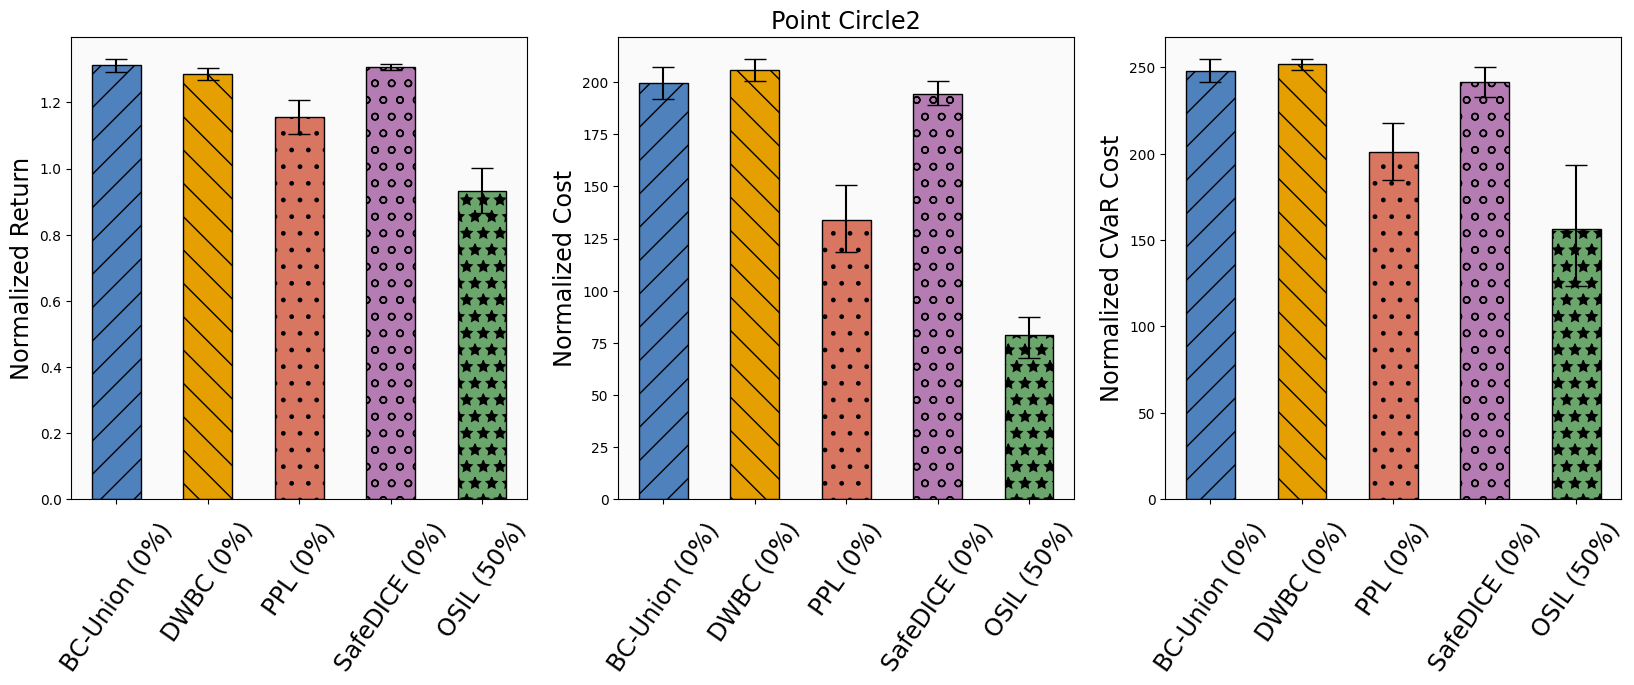

In [121]:
key="noisy_nonpref"
tasks = ["Point_Circle2",] 
# fig, ax = generate_performance_figures(tasks)
fig, ax = generate_noisy_barplot(tasks)
handles, labels = ax[0].get_legend_handles_labels()
# Create a single legend for all subplots
# fig.legend(handles, labels, loc='upper center', ncol=len(ALGOS), fontsize='xx-large')

#### Save figure

In [24]:
save_fig_path = f"{DATA_PATH}/{hyperparams}/../pdf_images/safecl/neg_50/{key}/norm_navigation_task.pdf"
fig.savefig(save_fig_path, format="pdf", bbox_inches='tight')

In [25]:
save_fig_path = f"{DATA_PATH}/{hyperparams}/../svg_images/safecl/neg_50/{key}/norm_navigation_task.svg"
fig.savefig(save_fig_path, format="svg", bbox_inches='tight')

In [26]:
save_fig_path = f"{DATA_PATH}/{hyperparams}/../png_images/safecl/neg_50/{key}/norm_navigation_task.png"
fig.savefig(save_fig_path, bbox_inches='tight')

##### Safety-Gymnasium

In [89]:
import safety_gymnasium as safety_gym

In [115]:
def get_env_image(env_name, version, ax):
    safety_env_name = f"Safety{env_name.replace('_', '')}-v{version}"
    e = safety_gym.make(safety_env_name, render_mode="rgb_array", camera_name="fixedfar")
    e.reset()
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    f = e.render()
    e.close()
    ax.imshow(f, cmap='viridis')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(env_name.replace("_", " "), fontsize=25)
    return ax

In [116]:
def add_env_figures(env_names, version):
    n = len(env_names)
    single_fig, single_ax = plt.subplots(1, n, figsize=(20, 8))
    for i, env_name in enumerate(env_names):
        _ = get_env_image(env_name, version, ax=single_ax[i])

    plt.subplots_adjust(hspace=0.15, wspace=0.1)
    plt.tight_layout() 
    return single_fig, single_ax

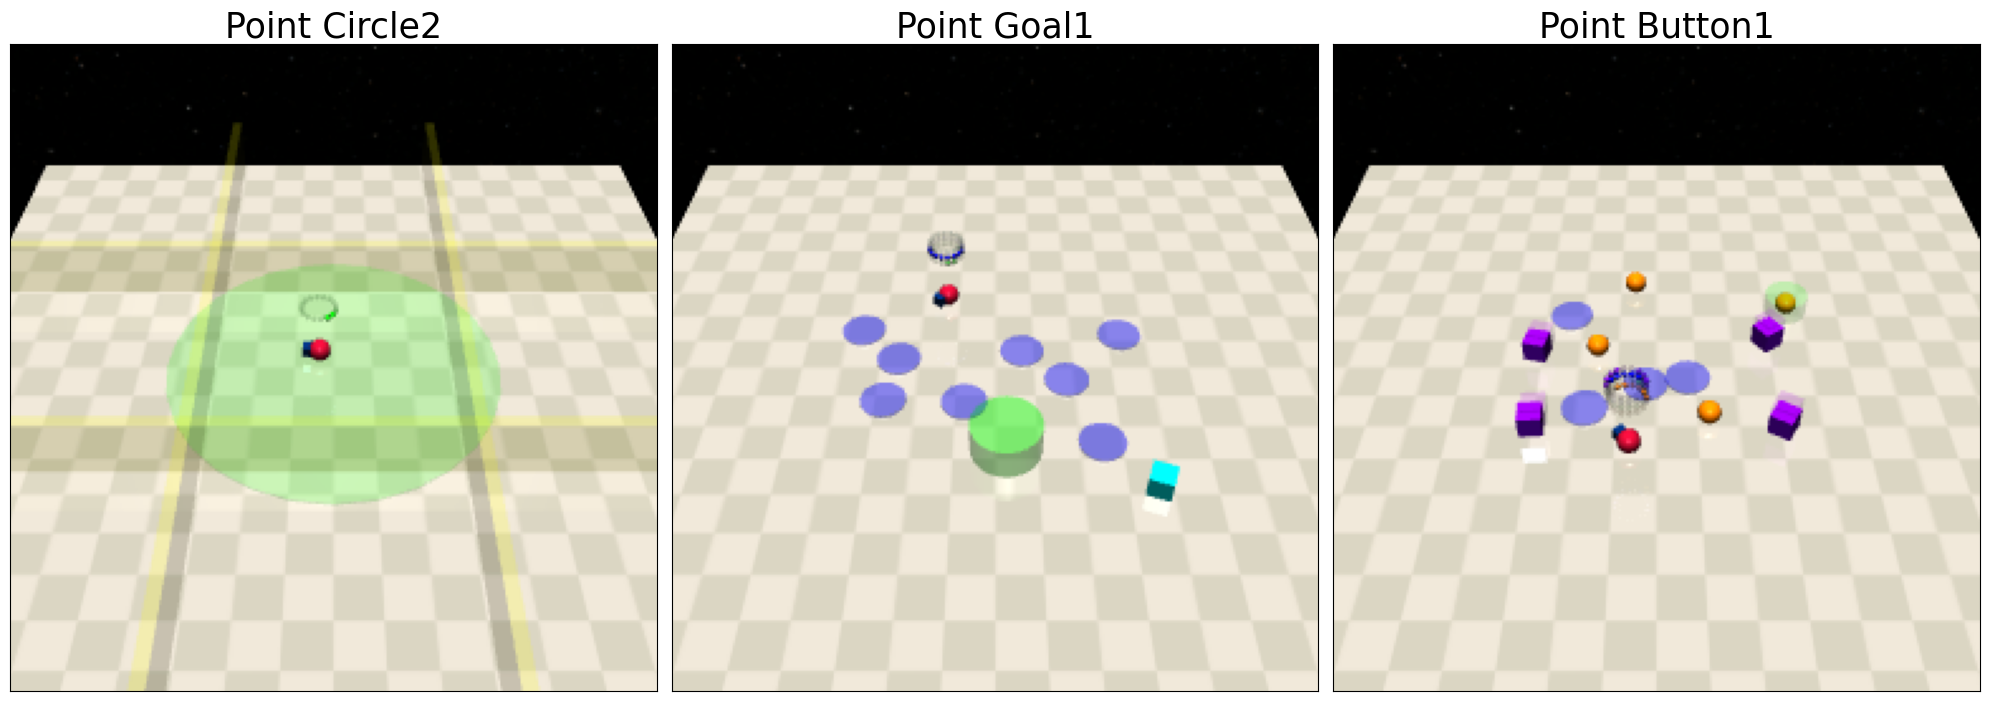

In [117]:
env_names = ["Point_Circle2", "Point_Goal1", "Point_Button1"]
# env_names = ["Walker2d_Velocity", "Swimmer_Velocity", "Ant_Velocity"] # Hopper_Velocity
version = 0
fig, ax = add_env_figures(env_names, version)


In [118]:
save_fig_path = f"{DATA_PATH}/svg_images/point_task.svg"
fig.savefig(save_fig_path, format="svg")